# Módulo 10 tarefa 2

Considere a mesma base de dados utilizada na tarefa 1 ```previsao_de_renda.csv```.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('previsao_de_renda.csv')
df['log_renda'] = np.log(df['renda'])

1) Com o que você viu em aula, faça uma análise das variáveis qualitativas (posse de imóvel e posse de veículo) para verificar se são boas preditoras de *renda*. Alguma delas parece discriminar *renda* de forma estatisticamente significante?

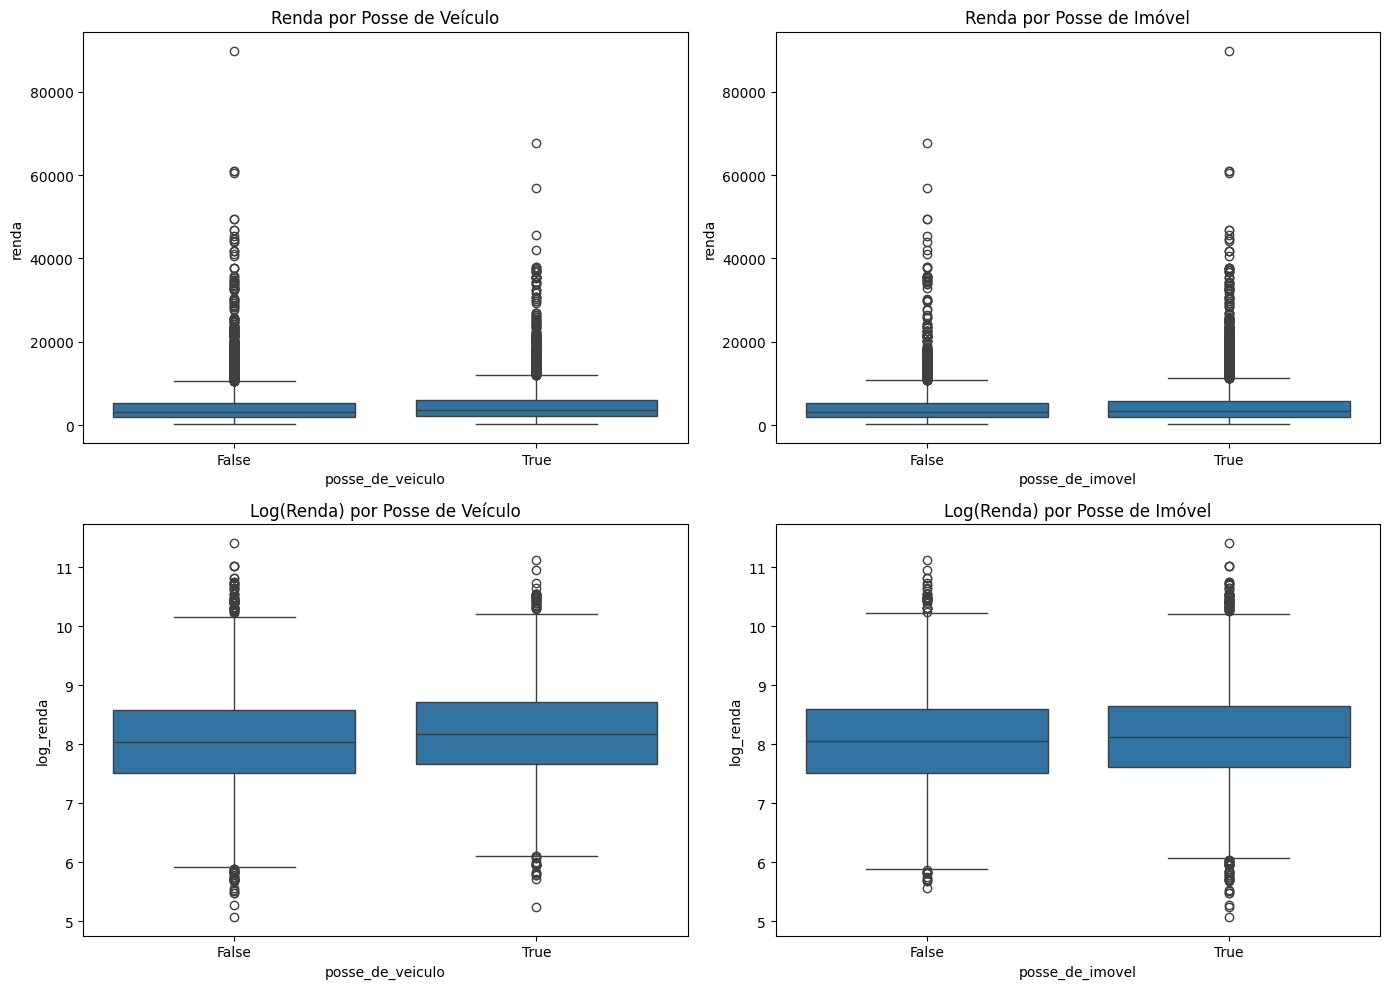


--- posse_de_veiculo ---
Média (True):  R$ 4992.58
Média (False): R$ 4390.51
T-statistic: 7.7817 | p-valor: 0.0000
Significante (p < 0.05)? Sim

--- posse_de_imovel ---
Média (True):  R$ 4721.05
Média (False): R$ 4426.97
T-statistic: 3.6545 | p-valor: 0.0003
Significante (p < 0.05)? Sim


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplots
sns.boxplot(data=df, x='posse_de_veiculo', y='renda', ax=axes[0, 0])
axes[0, 0].set_title('Renda por Posse de Veículo')

sns.boxplot(data=df, x='posse_de_imovel', y='renda', ax=axes[0, 1])
axes[0, 1].set_title('Renda por Posse de Imóvel')

# Com log_renda para melhor visualização
sns.boxplot(data=df, x='posse_de_veiculo', y='log_renda', ax=axes[1, 0])
axes[1, 0].set_title('Log(Renda) por Posse de Veículo')

sns.boxplot(data=df, x='posse_de_imovel', y='log_renda', ax=axes[1, 1])
axes[1, 1].set_title('Log(Renda) por Posse de Imóvel')

plt.tight_layout()
plt.show()

# Teste t de Student para verificar significância estatística
for var in ['posse_de_veiculo', 'posse_de_imovel']:
    grupo_true  = df[df[var] == True]['renda']
    grupo_false = df[df[var] == False]['renda']
    t_stat, p_valor = stats.ttest_ind(grupo_true, grupo_false)
    
    print(f"\n--- {var} ---")
    print(f"Média (True):  R$ {grupo_true.mean():.2f}")
    print(f"Média (False): R$ {grupo_false.mean():.2f}")
    print(f"T-statistic: {t_stat:.4f} | p-valor: {p_valor:.4f}")
    print(f"Significante (p < 0.05)? {'Sim' if p_valor < 0.05 else 'Não'}")